# Project Python Foundations: FoodHub Data Analysis

**Marks: 60**

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [ ]:
!jupyter nbconvert --to html /content/Boluwatito_PYF_Project_LearnerNotebook.ipynb

[NbConvertApp] Converting notebook /content/Boluwatito_PYF_Project_LearnerNotebook.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 23 image(s).
[NbConvertApp] Writing 2811625 bytes to /content/Boluwatito_PYF_Project_LearnerNotebook.html


### Understanding the structure of the data

In [ ]:
 #uncomment and run the following lines for Google Colab
 from google.colab import drive
 drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# read the data
df = pd.read_csv('/content/foodhub_order.csv')
# returns the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


#### Observations:

The DataFrame has 9 columns as mentioned in the Data Dictionary. Data in each row corresponds to the order placed by a customer.

### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
df.shape

(1898, 9)

#### Observations:
There are 1,898 rows and 9 columns in the foodhub_order table.


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
# Use info() to print a concise summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
All columns have 1898 observations.

The order_id, customer_id, food_preparation_time, and delivery_time columns have the integer datatype.

The restaurant_name, cuisine_type, day_of_the_week, and rating columns have the datatype object, which portrays an object datatype.

The cost_of_the_order column has a float datatype.


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations:
There are no missing values in the dataset.

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.0,1.477496e+06,548.049724,1476547.00,1477021.25,1477495.50,1.477970e+06,1478444.00
customer_id,1898.0,1.711685e+05,113698.139743,1311.00,77787.75,128600.00,2.705250e+05,405334.00
cost_of_the_order,1898.0,1.649885e+01,7.483812,4.47,12.08,14.14,2.229750e+01,35.41
food_preparation_time,1898.0,2.737197e+01,4.632481,20.00,23.00,27.00,3.100000e+01,35.00
delivery_time,1898.0,2.416175e+01,4.972637,15.00,20.00,25.00,2.800000e+01,33.00


#### Observations:
The minimum time taken for food to be prepared, once an order is place, is 20 minutes.

The average time taken for food to be prepared, once an order is place, is 27.37 minutes.

The maximum time taken for food to be prepared, once an order is place, is 35 minutes.

These results may depend on different conditions. For example the amount of workers available that day, efficiency of the machines et cetera.

The difference between the 3rd quartile and the maximum values do not vary much in the columns.


### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
rating = df.rating
rating

,rating
0,Not given
1,Not given
2,5
3,3
4,4
...,...
1893,5
1894,5
1895,Not given
1896,5


In [ ]:
count = 0
for i in rating:
  if i == "Not given":
    count+=1

print(count)

736


#### Observations:
736 orders where not given ratings.





### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

In [ ]:
df.columns

Index(['order_id', 'customer_id', 'restaurant_name', 'cuisine_type',
       'cost_of_the_order', 'day_of_the_week', 'rating',
       'food_preparation_time', 'delivery_time'],
      dtype='object')

<Axes: xlabel='cuisine_type', ylabel='count'>

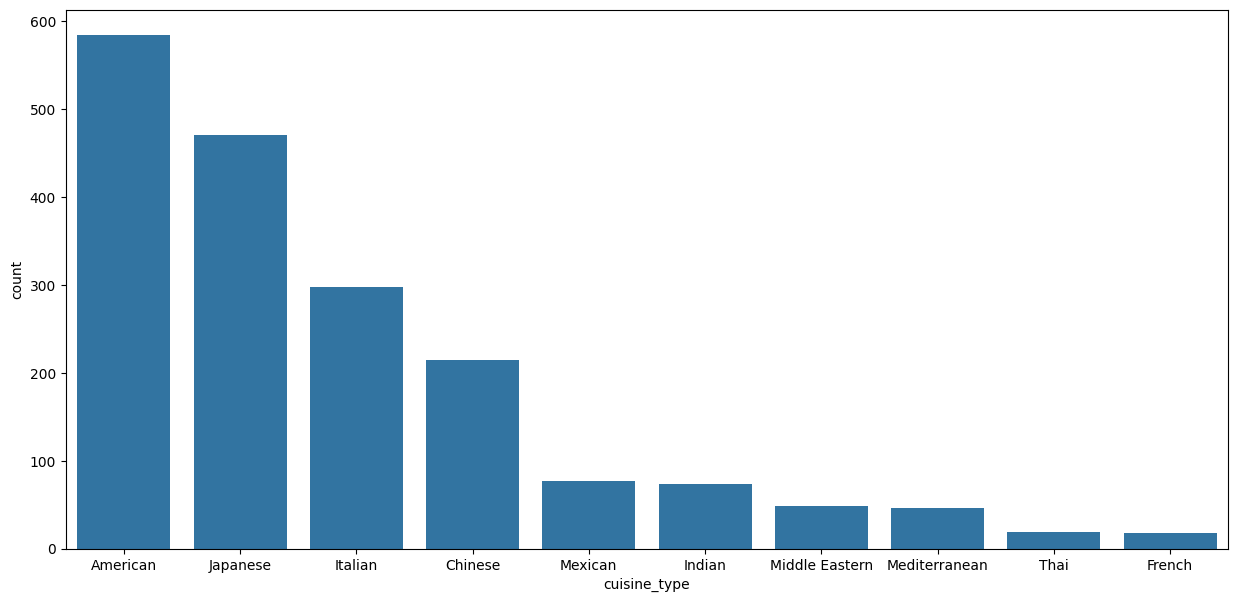

In [ ]:
plt.figure(figsize = (15, 7))
sns.countplot(data = df, x = 'cuisine_type', order = df['cuisine_type'].value_counts().head(10).index)

<Axes: xlabel='restaurant_name', ylabel='count'>

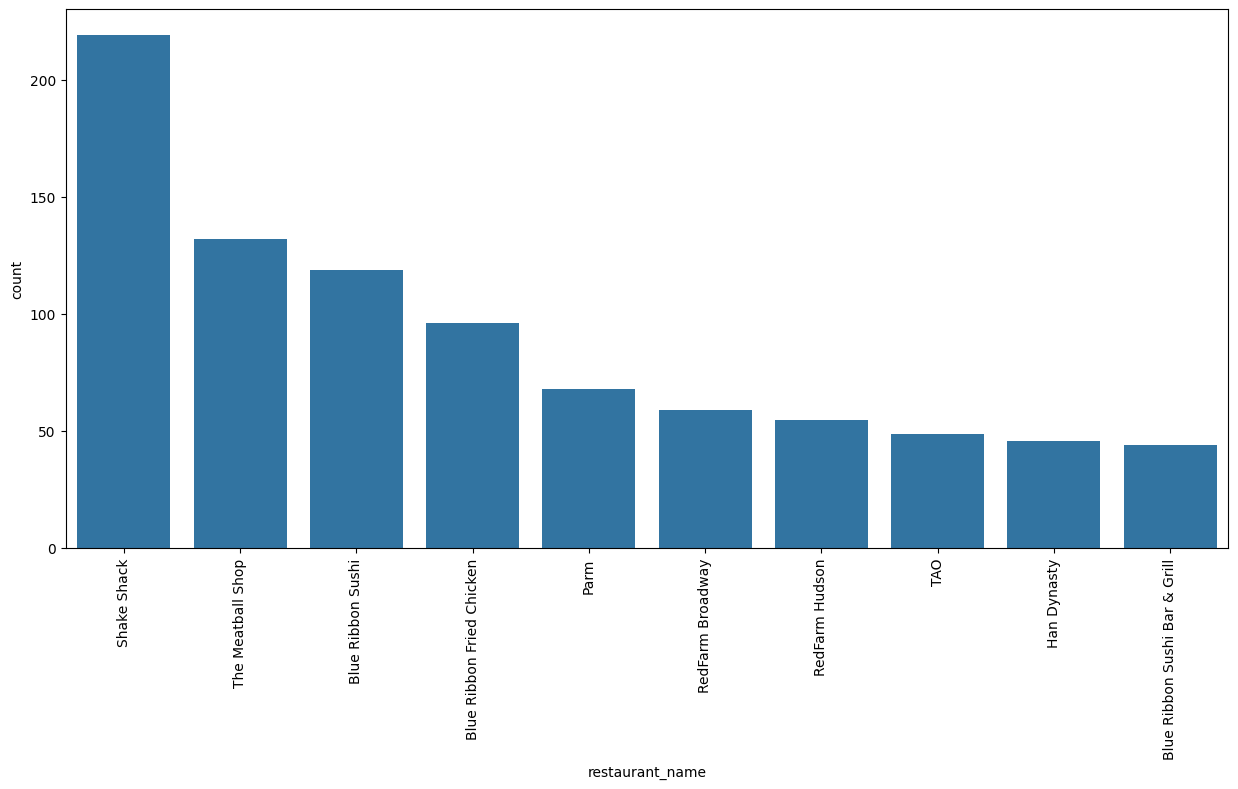

In [ ]:
plt.figure(figsize = (15, 7))
plt.xticks(rotation = 90)
sns.countplot(data = df, x = 'restaurant_name', order = df['restaurant_name'].value_counts().head(10).index)

<Axes: xlabel='day_of_the_week', ylabel='count'>

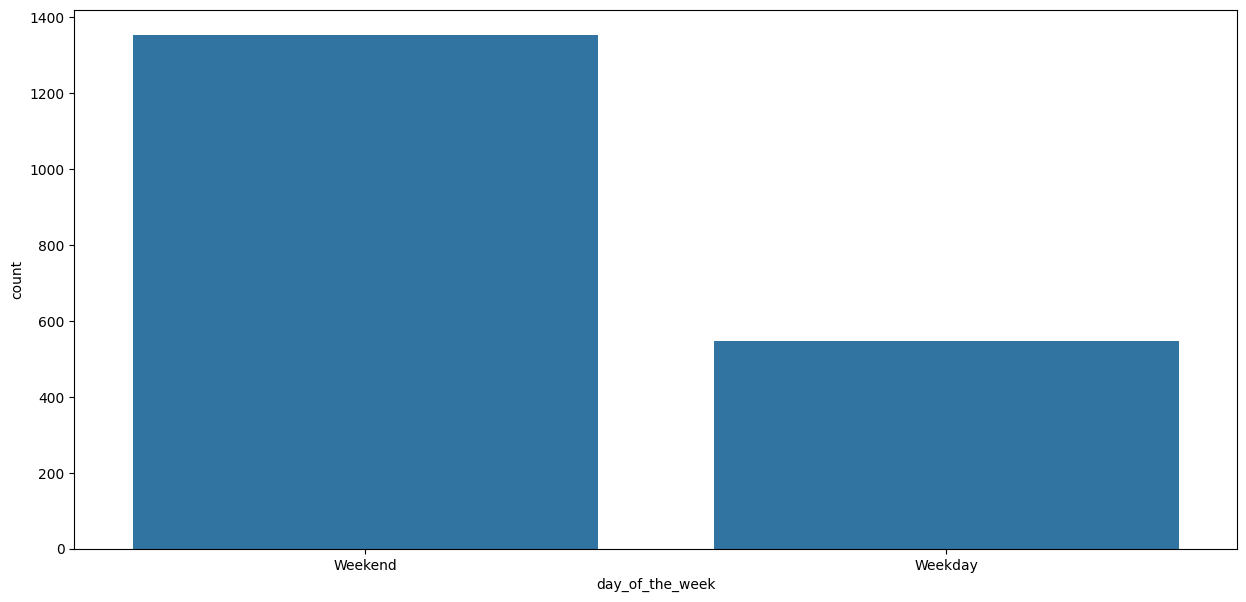

In [ ]:
plt.figure(figsize = (15, 7))
sns.countplot(data = df, x = 'day_of_the_week', order = df['day_of_the_week'].value_counts().head(10).index)

<Axes: xlabel='cost_of_the_order', ylabel='Count'>

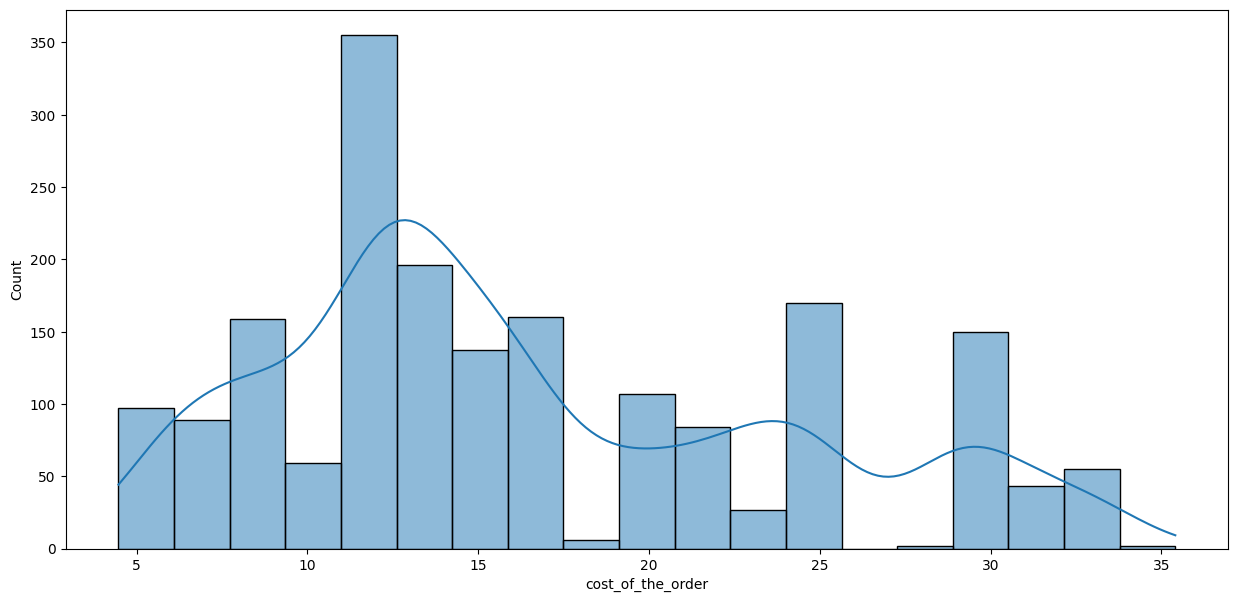

In [ ]:
plt.figure(figsize =(15,7))
sns.histplot(data =df, x ='cost_of_the_order', kde = True)

<Axes: xlabel='cost_of_the_order'>

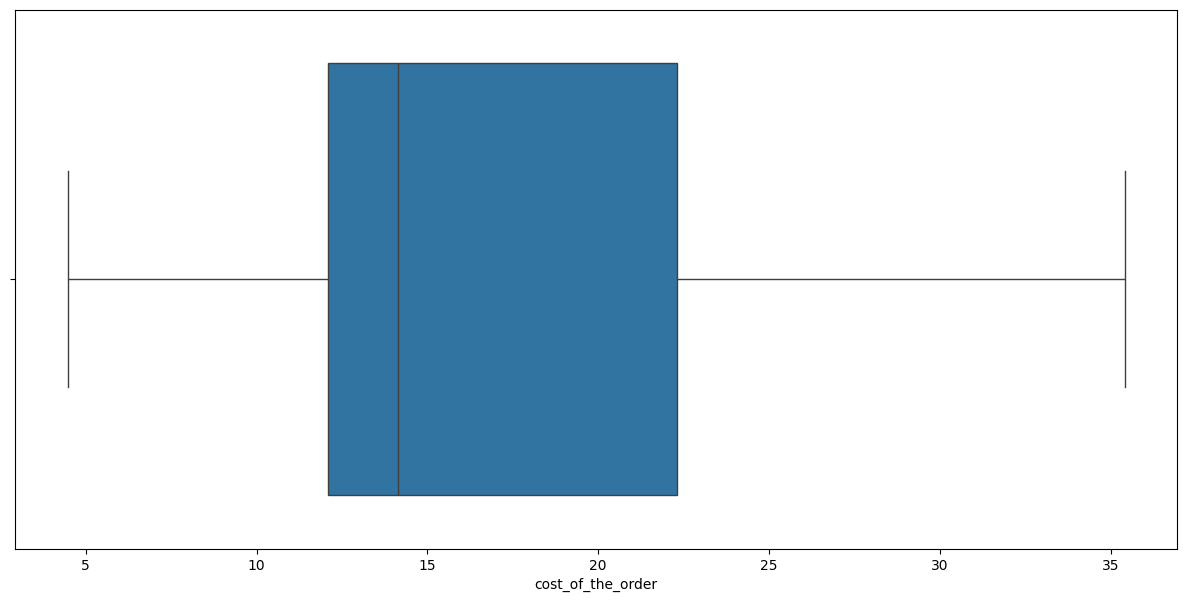

In [ ]:
plt.figure(figsize =(15,7))
sns.boxplot(data =df, x ='cost_of_the_order')

<Axes: xlabel='rating', ylabel='Count'>

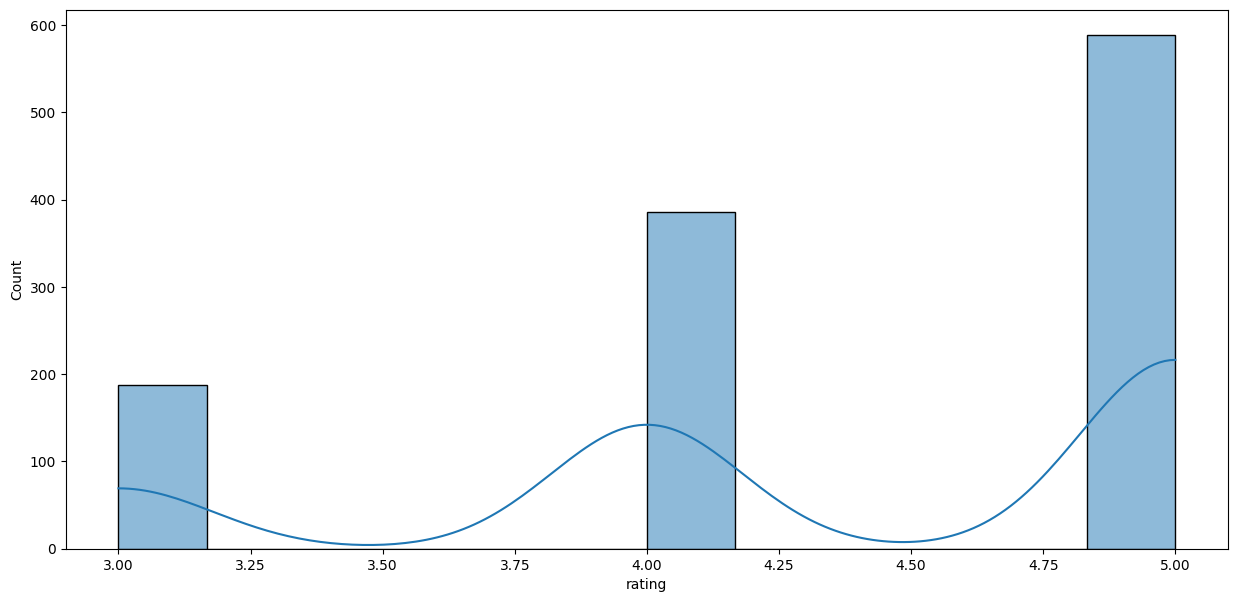

In [ ]:
plt.figure(figsize =(15,7))
sns.histplot(data =df, x ='rating', kde = True)

<Axes: xlabel='rating'>

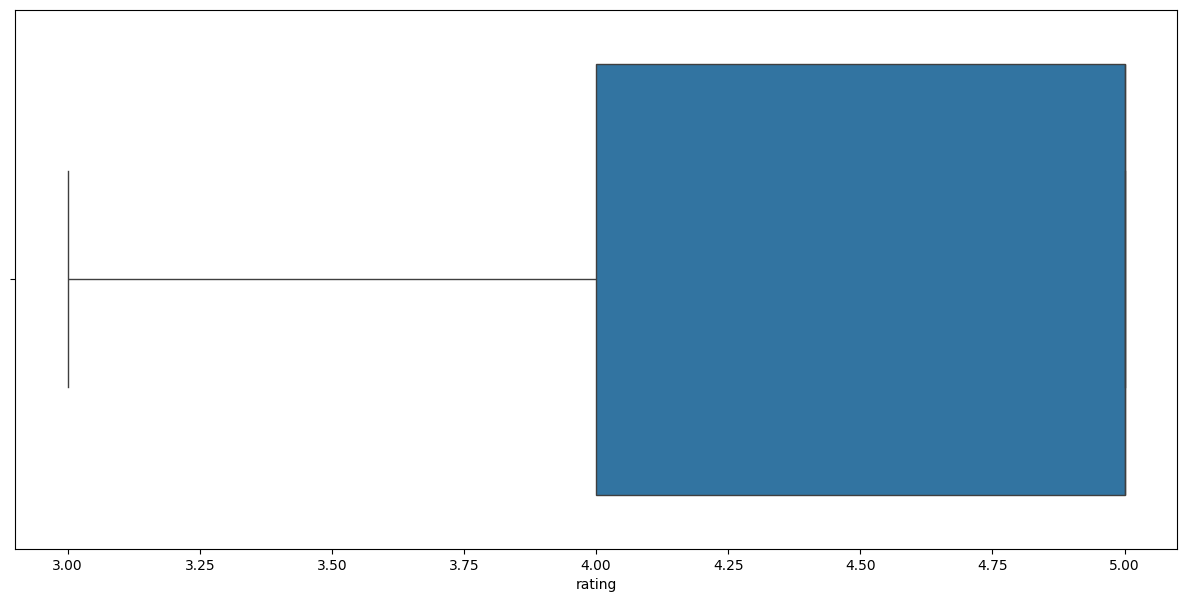

In [ ]:
plt.figure(figsize =(15,7))
sns.boxplot(data =df, x ='rating')

<Axes: xlabel='food_preparation_time', ylabel='Count'>

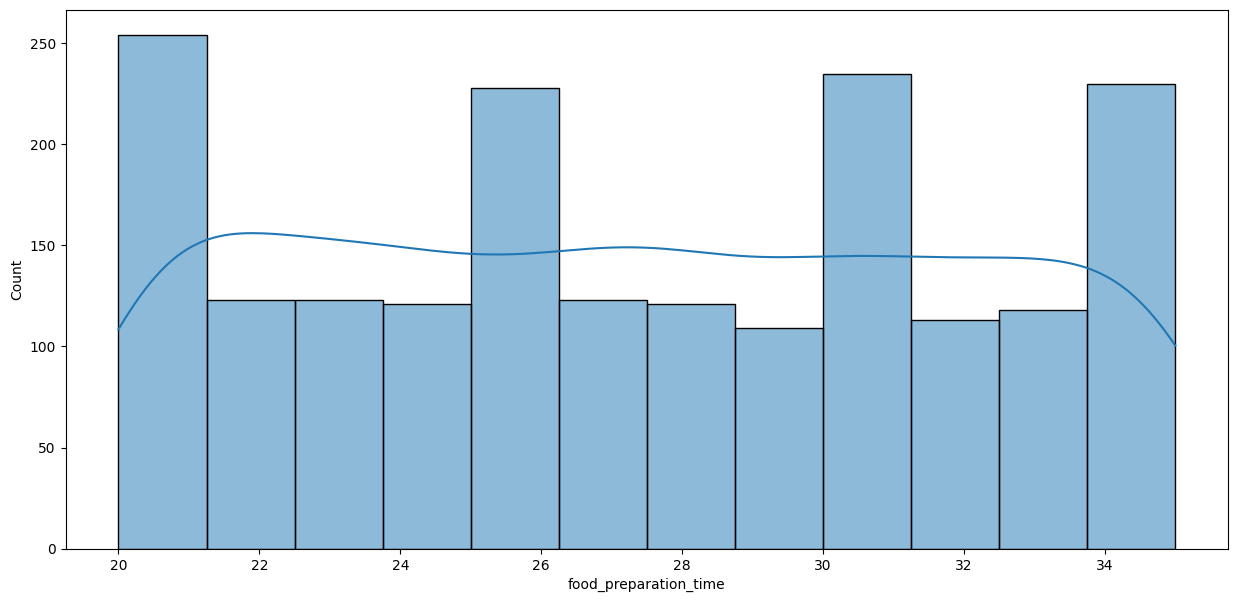

In [ ]:
plt.figure(figsize =(15,7))
sns.histplot(data =df, x ='food_preparation_time', kde = True)

<Axes: xlabel='food_preparation_time'>

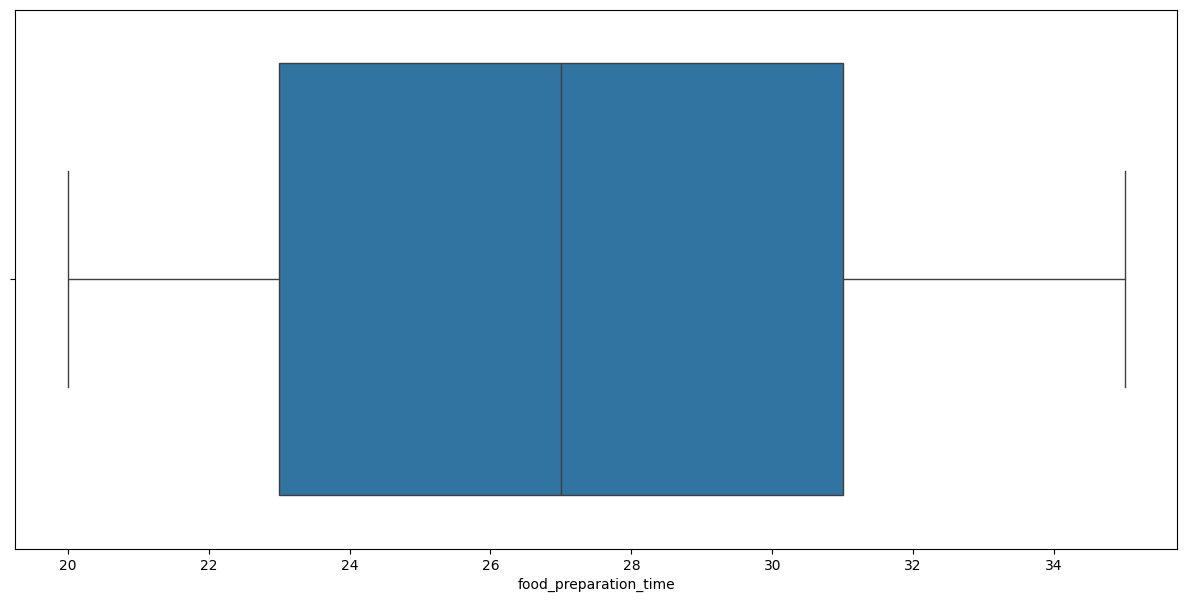

In [ ]:
plt.figure(figsize =(15,7))
sns.boxplot(data =df, x ='food_preparation_time')

<Axes: xlabel='delivery_time', ylabel='Count'>

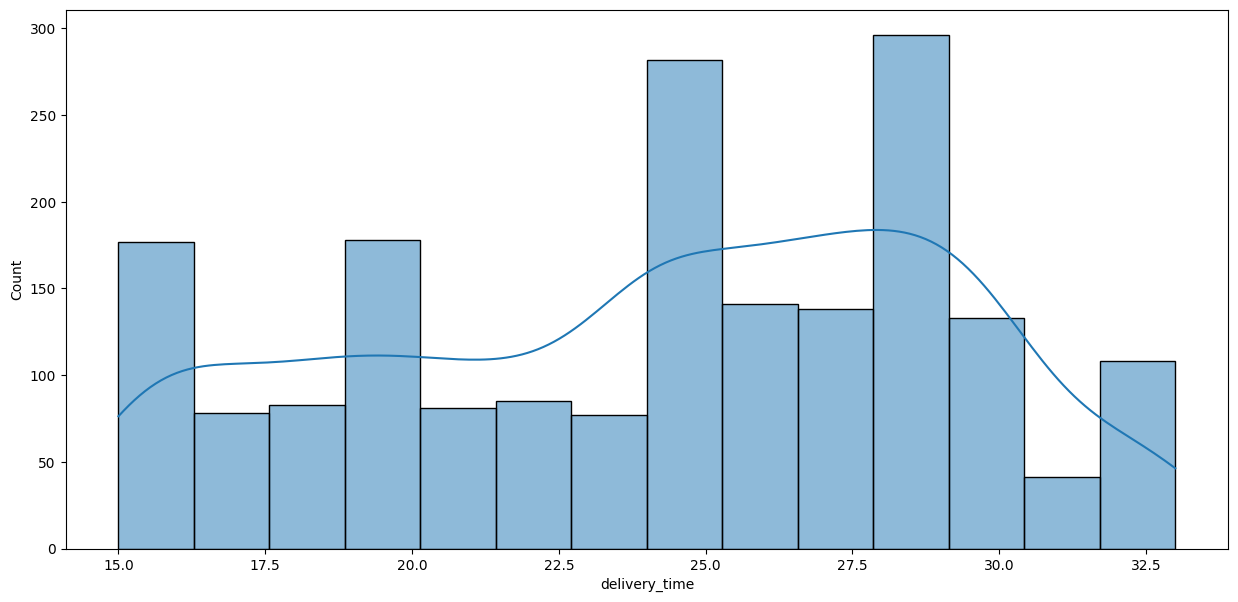

In [ ]:
plt.figure(figsize =(15,7))
sns.histplot(data =df, x ='delivery_time', kde = True)

<Axes: xlabel='delivery_time'>

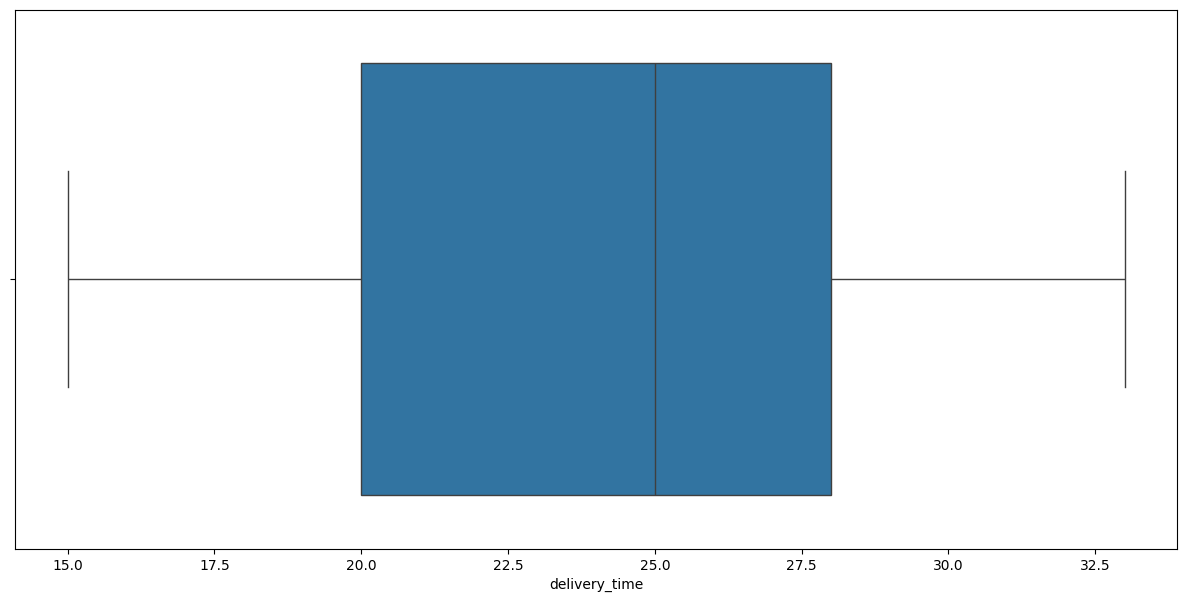

In [ ]:
plt.figure(figsize =(15,7))
sns.boxplot(data =df, x ='delivery_time')

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
df['restaurant_name'].value_counts().head()

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:
Shake Shack has the highest number of orders of 219 orders.

The Meatball Shop comes in second with 132 total orders.

Blue Ribbon Sushi comes in third with 119 total orders.

Blue Ribbon Fried Chicken comes in fourth with 96 total orders.

Parm in fifth with 68 total orders.

This could be as a result of a number of factors. For example, the menu options and cuisine differs.

Also, customer preference varies.


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
df[df['day_of_the_week'] == 'Weekend']['cuisine_type'].value_counts().head(1)

,count
cuisine_type,
American,415


#### Observations:
American cuisine is the most popular cuisine on weekends.

This may be due to customer preferences, menu options et cetera.



### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
order_over_20_percent = round(100 * len(df[df['cost_of_the_order'] > 20])/len(df),2)

print(f"{order_over_20_percent}% of the orders cost more than 20 dollars.")




29.24% of the orders cost more than 20 dollars.


#### Observations:
Approximately, 29.24% of the orders cost more than 20 dollars.

This could be due to long delivery time which causes a higher fee.


### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
mean_del_time = round(df['delivery_time'].mean(),2)
print(mean_del_time)

24.16


#### Observations:
The mean order delivery time is approximately 24.16 minutes.

Traffick, weather and many other factors may cause this result.


### **Question 11:** The company has decided to give 20% discount vouchers to the top 5 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
order_count = df.groupby(['customer_id'])['order_id'].count().reset_index()
order_count.rename(columns={'order_id':'no_of_orders'},inplace=True)
order_count.sort_values(ascending=False, by= 'no_of_orders').head()


,customer_id,no_of_orders
116,52832,13
84,47440,10
333,83287,9
839,250494,8
870,276192,7


#### Observations:
Customer 52832 is the most frequent customer with 13 total orders.

Customer 47440 is the second most frequent customer with 10 total orders.

Customer 83287 is the third most frequent customer with 9 total orders.

Customer 250494 is the fourth most frequent customer with 8 total orders.

Customer 276192 is the fifth most frequent customer with 7 total orders.

This could be due to preference, proximity, menu options, et cetera.

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


<Figure size 1500x700 with 0 Axes>

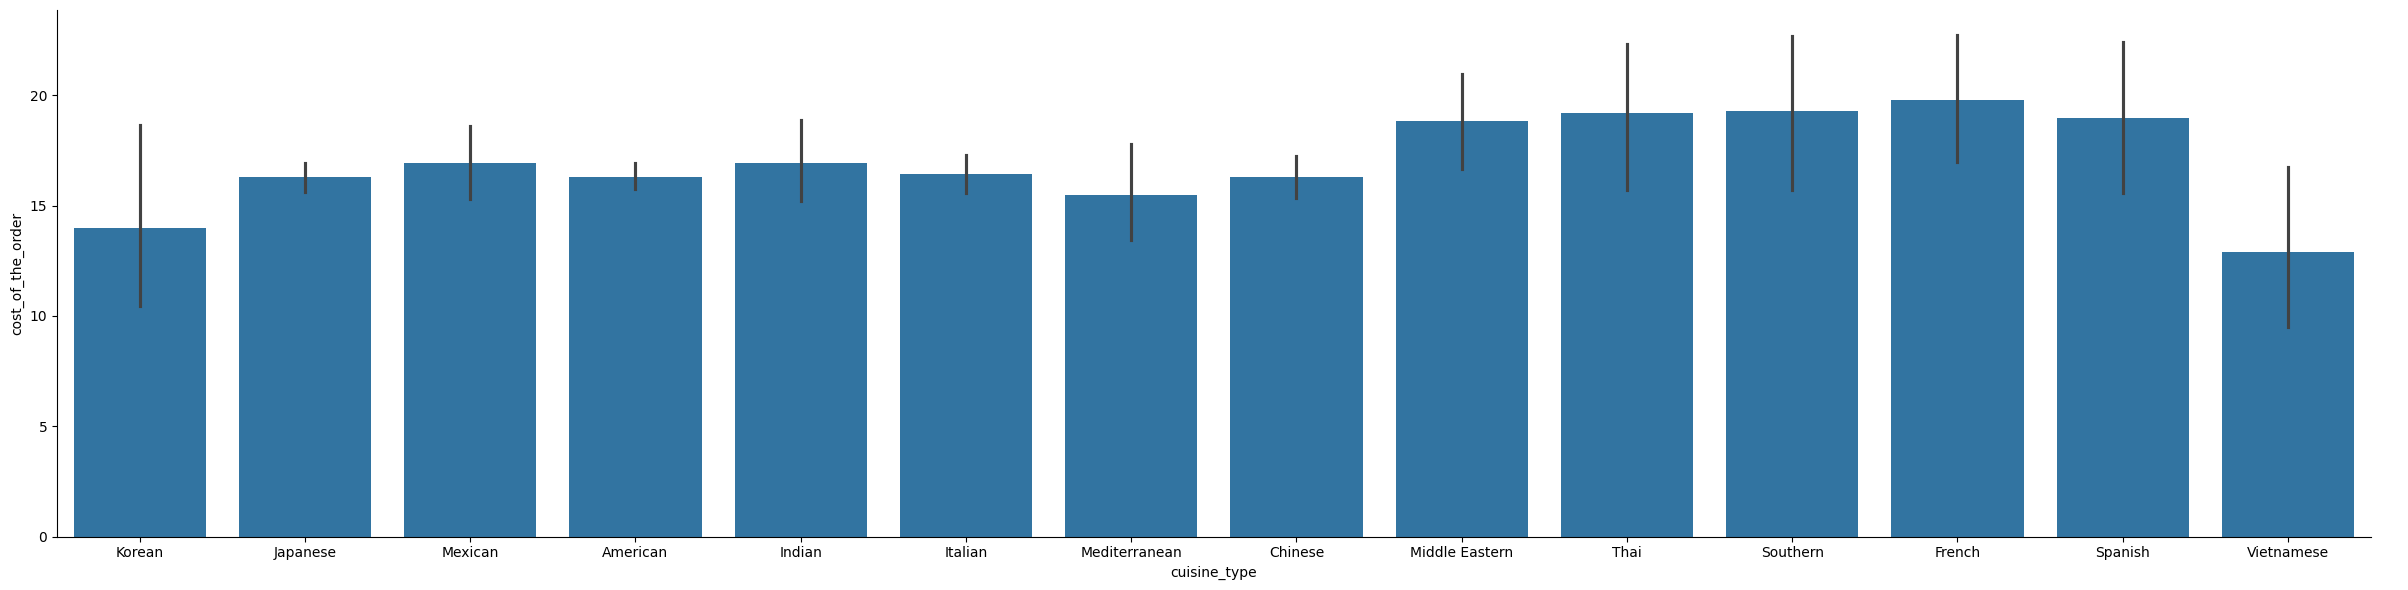

In [ ]:
sns.catplot(data = df, x = 'cuisine_type', y = 'cost_of_the_order', kind = 'bar', height = 6, aspect = 4)

#### Observations:

The French cuisine has the highest cost of orders, with about 20 dollars. This may be due to quality, type of ingredients et cetera. However, the Vietnamese cuisine has the lowest cost of orders, with about 12 dollars.



/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 140 (\x8c) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 142 (\x8e) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 140 (\x8c) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 142 (\x8e) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 140 (\x8c) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 142 (\x8e) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)


<Figure size 1500x700 with 0 Axes>

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 140 (\x8c) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 142 (\x8e) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


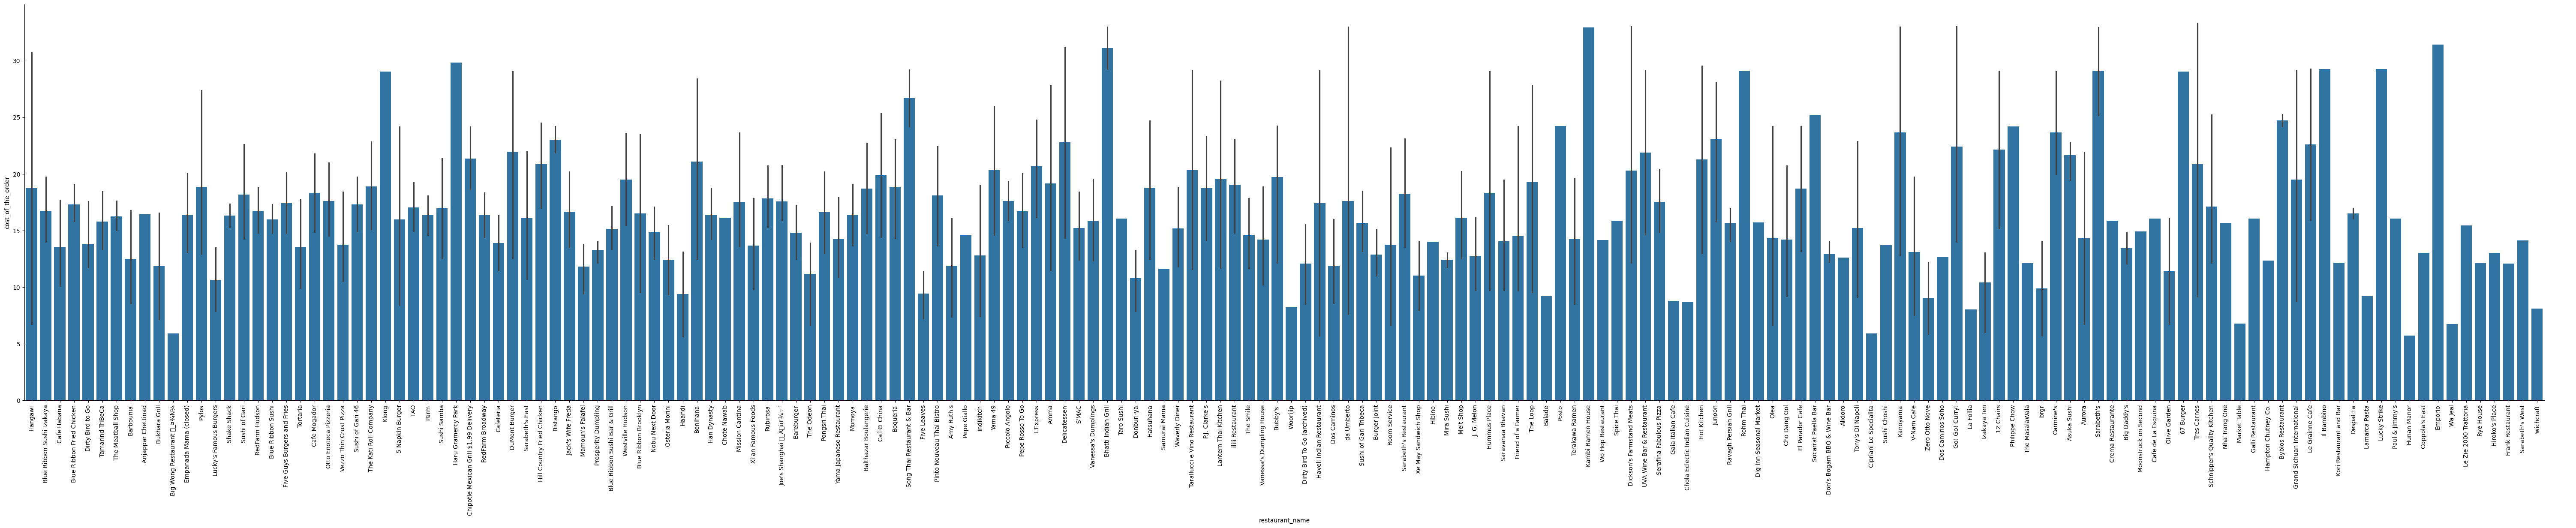

In [ ]:
plt.figure(figsize=(15,7))
sns.catplot(data = df, x = 'restaurant_name', y = 'cost_of_the_order', kind = 'bar', height = 10, aspect = 6, order = df['restaurant_name'])
plt.xticks(rotation = 90)
%matplotlib inline

#### Observations:

Kambi Ramen House has the highest cost of orders with about 32 dollars, while Big Wong Restaurant has the lowest cost of orders of about 6 dollars.

This could be due to location, menu, et cetera.

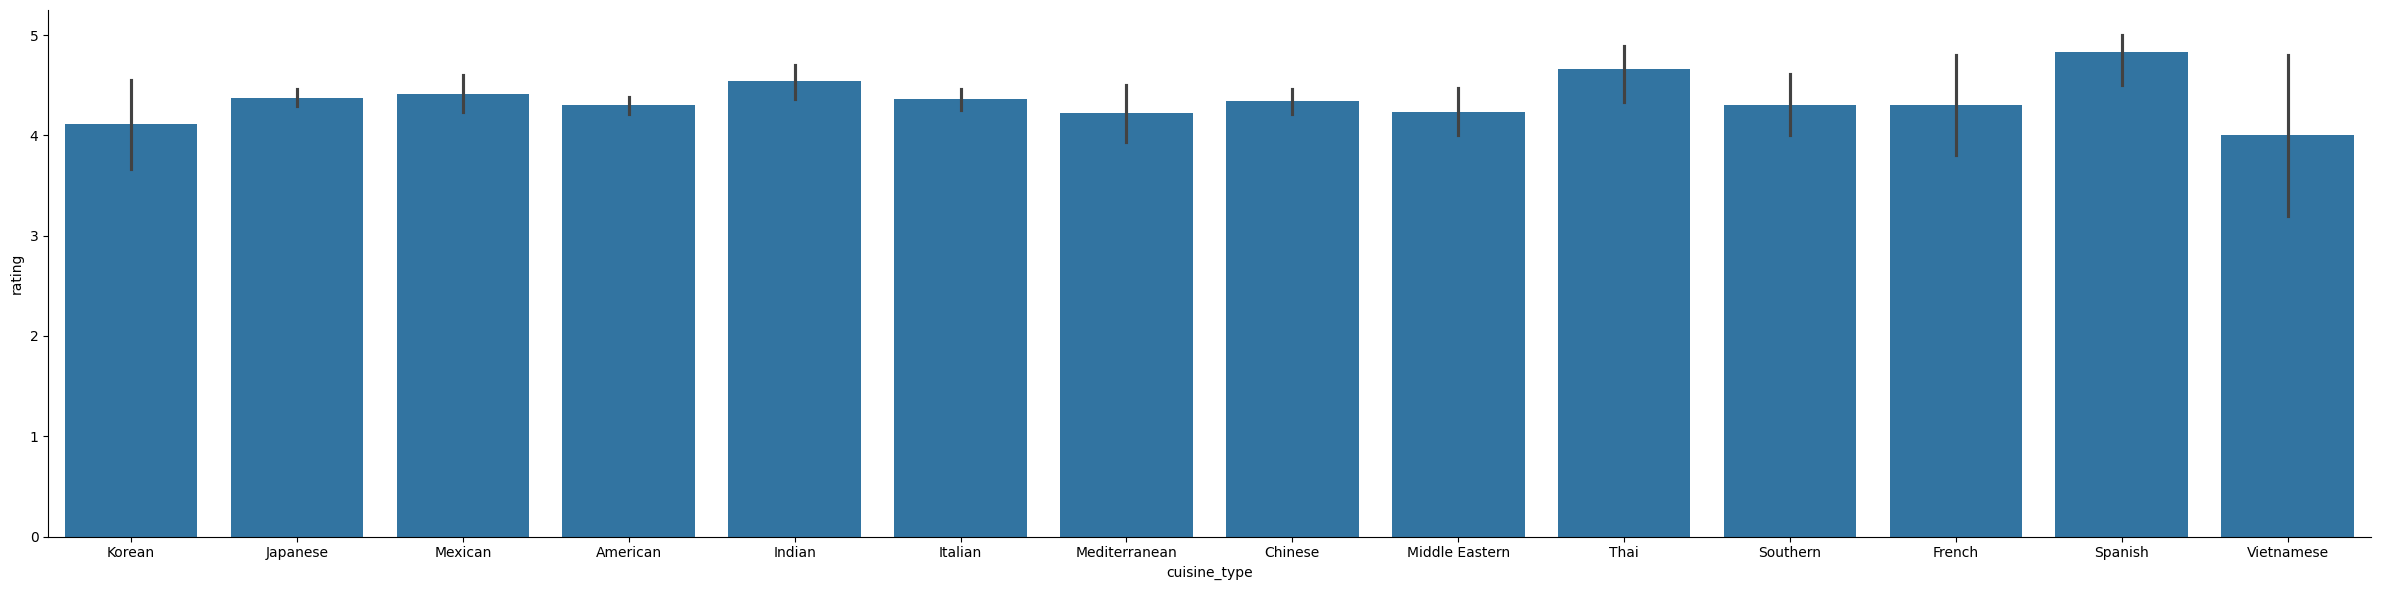

In [ ]:
sns.catplot(data = df, x = 'cuisine_type', y = 'rating', kind = 'bar', height = 6, aspect = 4)

#### Observations:

Spanish cuisine has the highest rating of approximately 4.8, while Vietnamese has the lowest rating of approximately 4.1.

Southern and French cuisines have the same rating of approximately 4.3.

This could be due to food preparation and delivery time, quality of food et cetera.




/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 140 (\x8c) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 142 (\x8e) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 140 (\x8c) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 142 (\x8e) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 140 (\x8c) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 142 (\x8e) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)


<Figure size 1500x700 with 0 Axes>

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 140 (\x8c) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 142 (\x8e) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


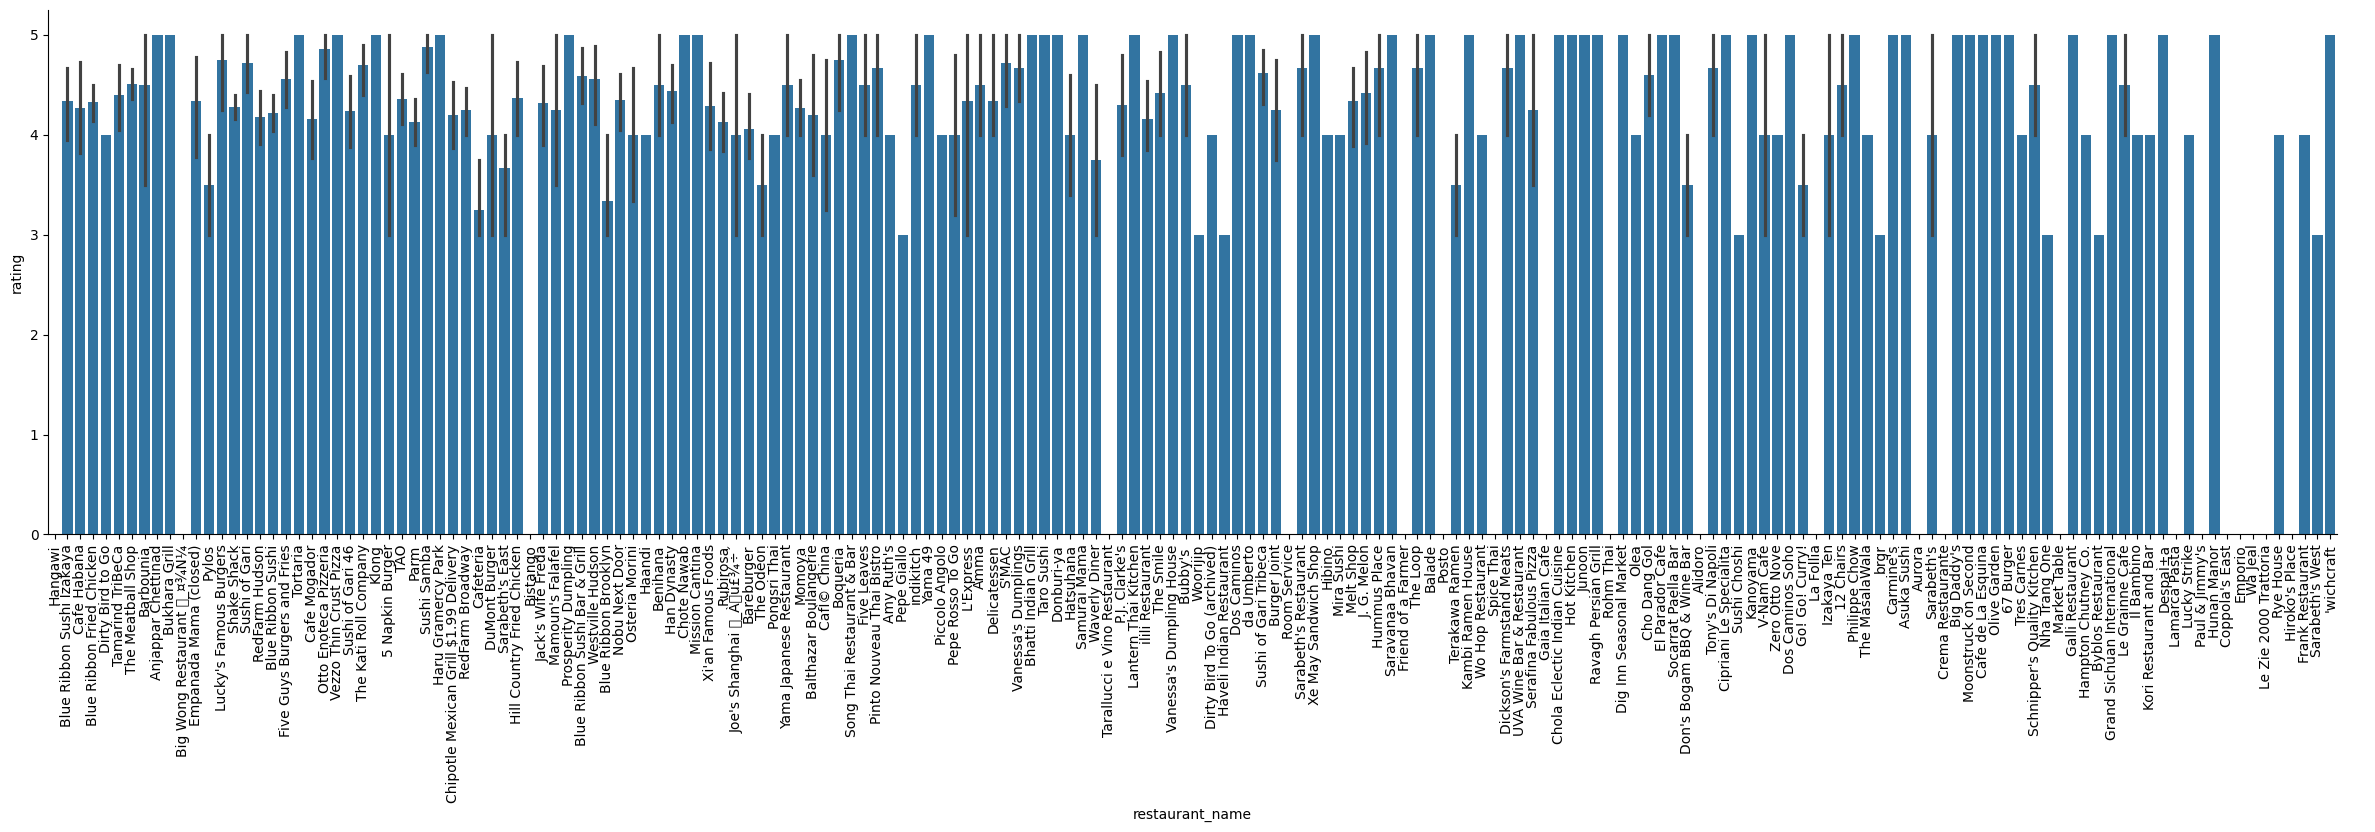

In [ ]:
plt.figure(figsize=(15,7))
sns.catplot(data = df, x = 'restaurant_name', y = 'rating', kind = 'bar', height = 6, aspect = 4)
plt.xticks(rotation = 90)
%matplotlib inline

#### Observation:

Some restaurants have a rating of 5,

Big Wong Restaurant, Bistango, Taralucci e Vino Restaurant, Room Service, Friend of a Farmer, Posto, Spice Thai, Gaia Italian Cafe, Rohm Thai, Alidoro, La Follia, Aurora, Crema Restaurante, Market Table, Lamarca Pasta, Paul & Jimmy's, Emporio, Wa Jeal, Le Zie 2000 Trattoria and Hiroko's Place all no rating.

This could be due to the quality of service, food preparation and delivery times et cetera.


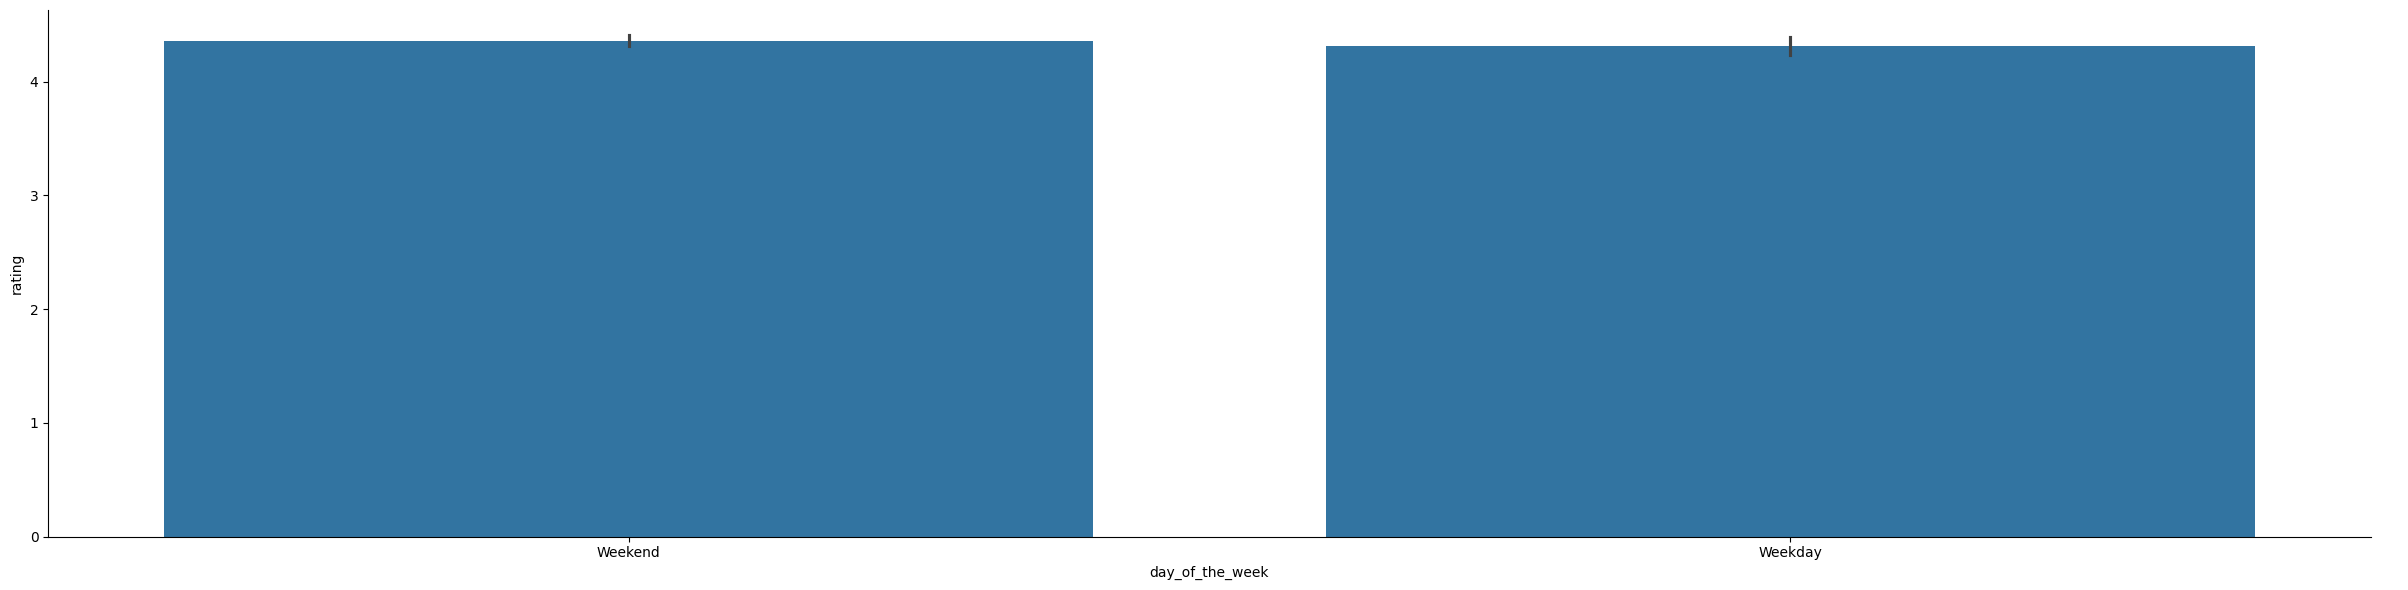

In [ ]:
sns.catplot(data = df, x = 'day_of_the_week', y = 'rating', kind = 'bar', height = 6, aspect = 4)

#### Observations:

The weekend has a rating of 4.5, while the weekday has a rating of about 4.3.

This is only a slight difference.

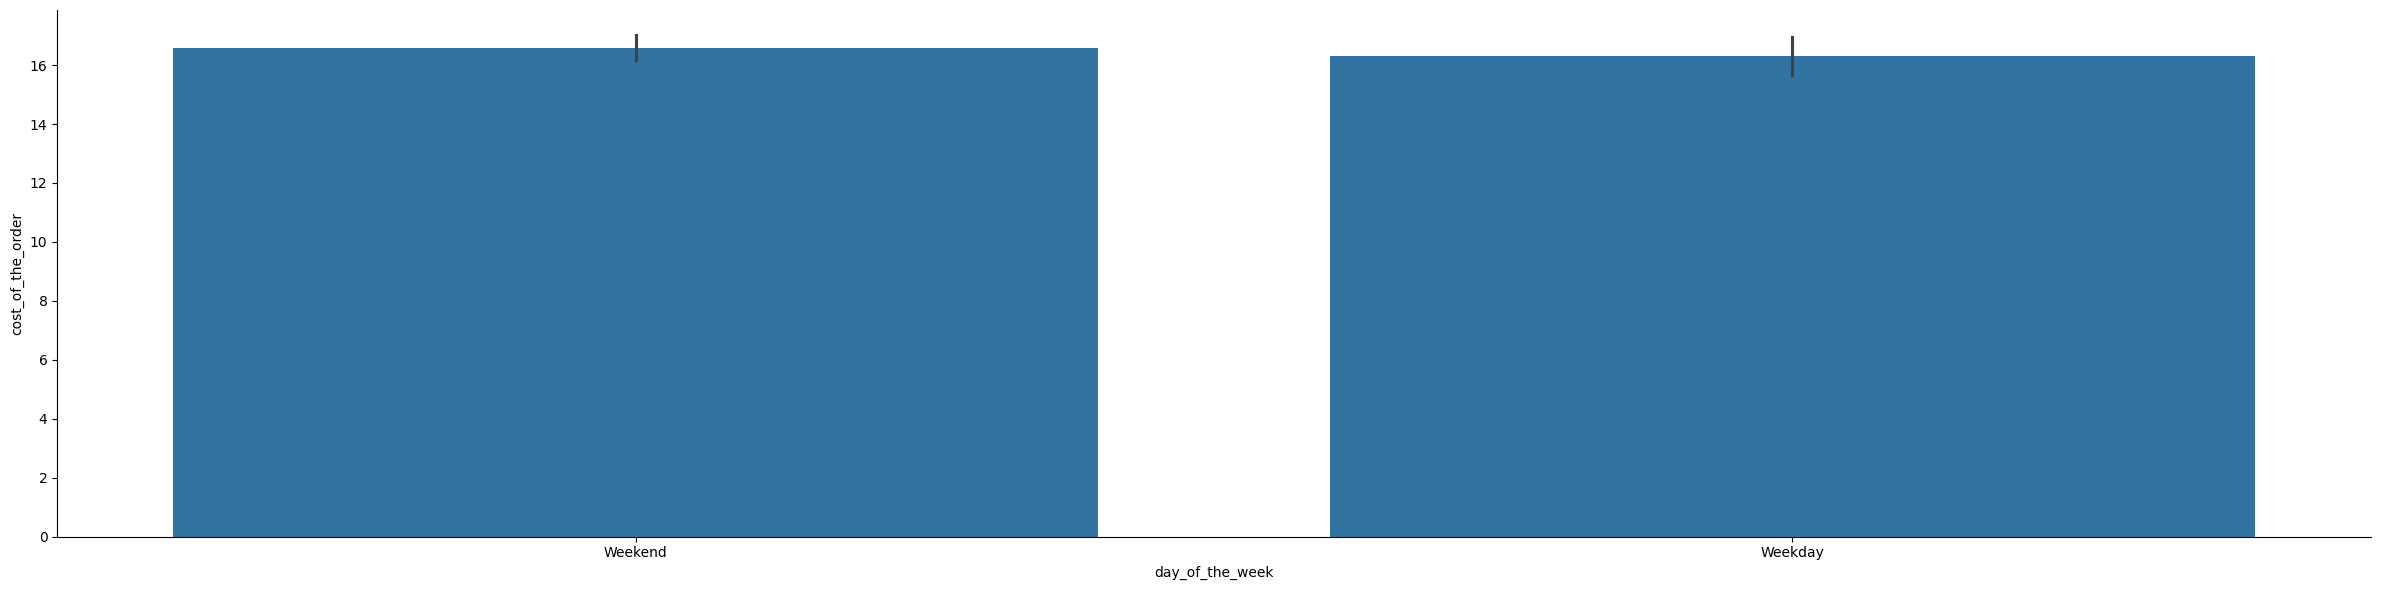

In [ ]:
sns.catplot(data = df, x = 'day_of_the_week', y = 'cost_of_the_order', kind = 'bar', height = 6, aspect = 4)

#### Observations:

Approximately, the weekend has 16.3 dollars as its cost of orders, while the weekday has 16.1 dollrs as its cost of orders.

This could be due to More customers during the weekends so as to maximise profit.

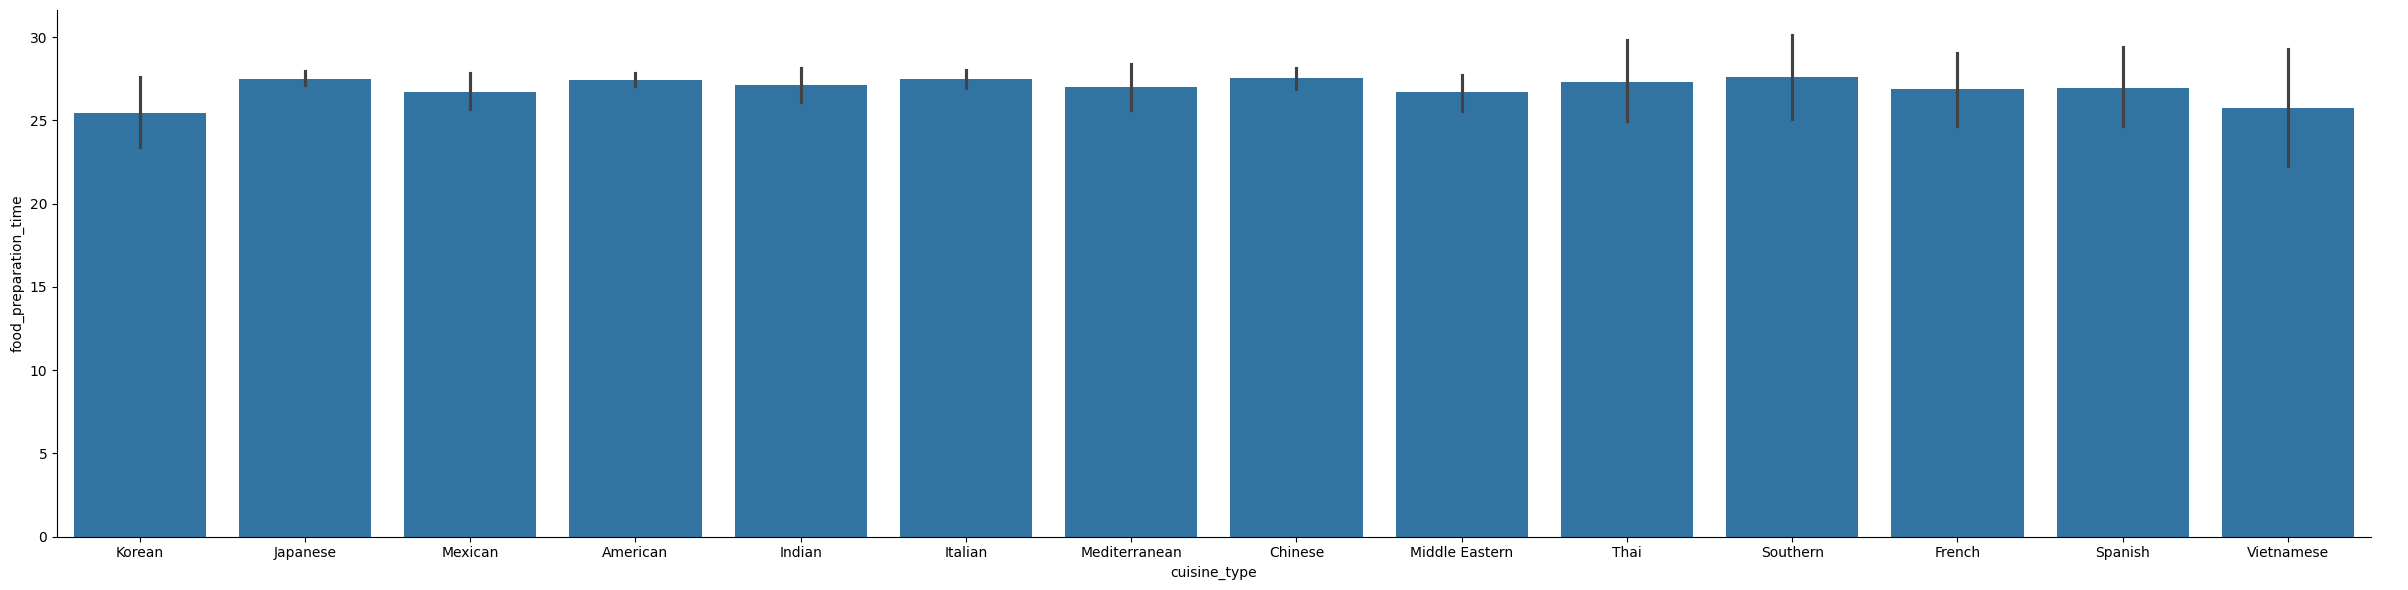

In [ ]:
sns.catplot(data = df, x = 'cuisine_type', y = 'food_preparation_time', kind = 'bar', height = 6, aspect = 4)

#### Observations:

The Southern cuisine has the highest food preparation time of about 27 minutes, while the Korean cuisine has the lowest food preparation time of about 25.5 minutes.

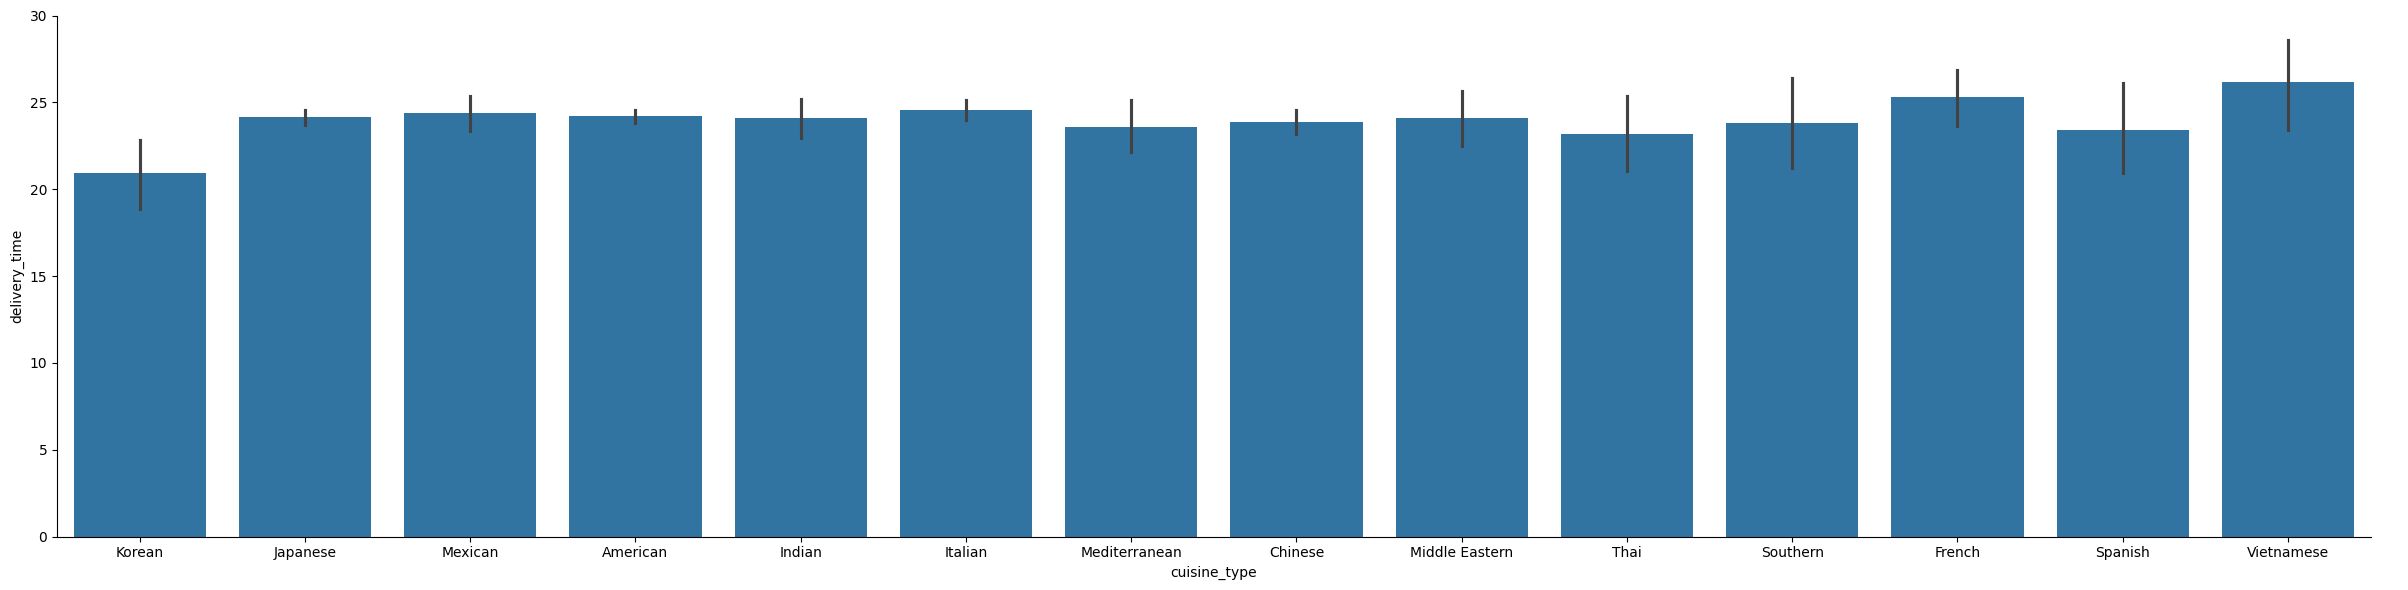

In [ ]:
sns.catplot(data = df, x = 'cuisine_type', y = 'delivery_time', kind = 'bar', height = 6, aspect = 4)

#### Observations:

The Vietnames cuisine has the highest delivery time of about 26 minutes, while the Korean cuisine has the lowest delivery time of about 21 minutes.

This could be due to complexity in dish preparation, et cetera.


/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 140 (\x8c) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 142 (\x8e) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 140 (\x8c) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 142 (\x8e) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 140 (\x8c) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 142 (\x8e) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core

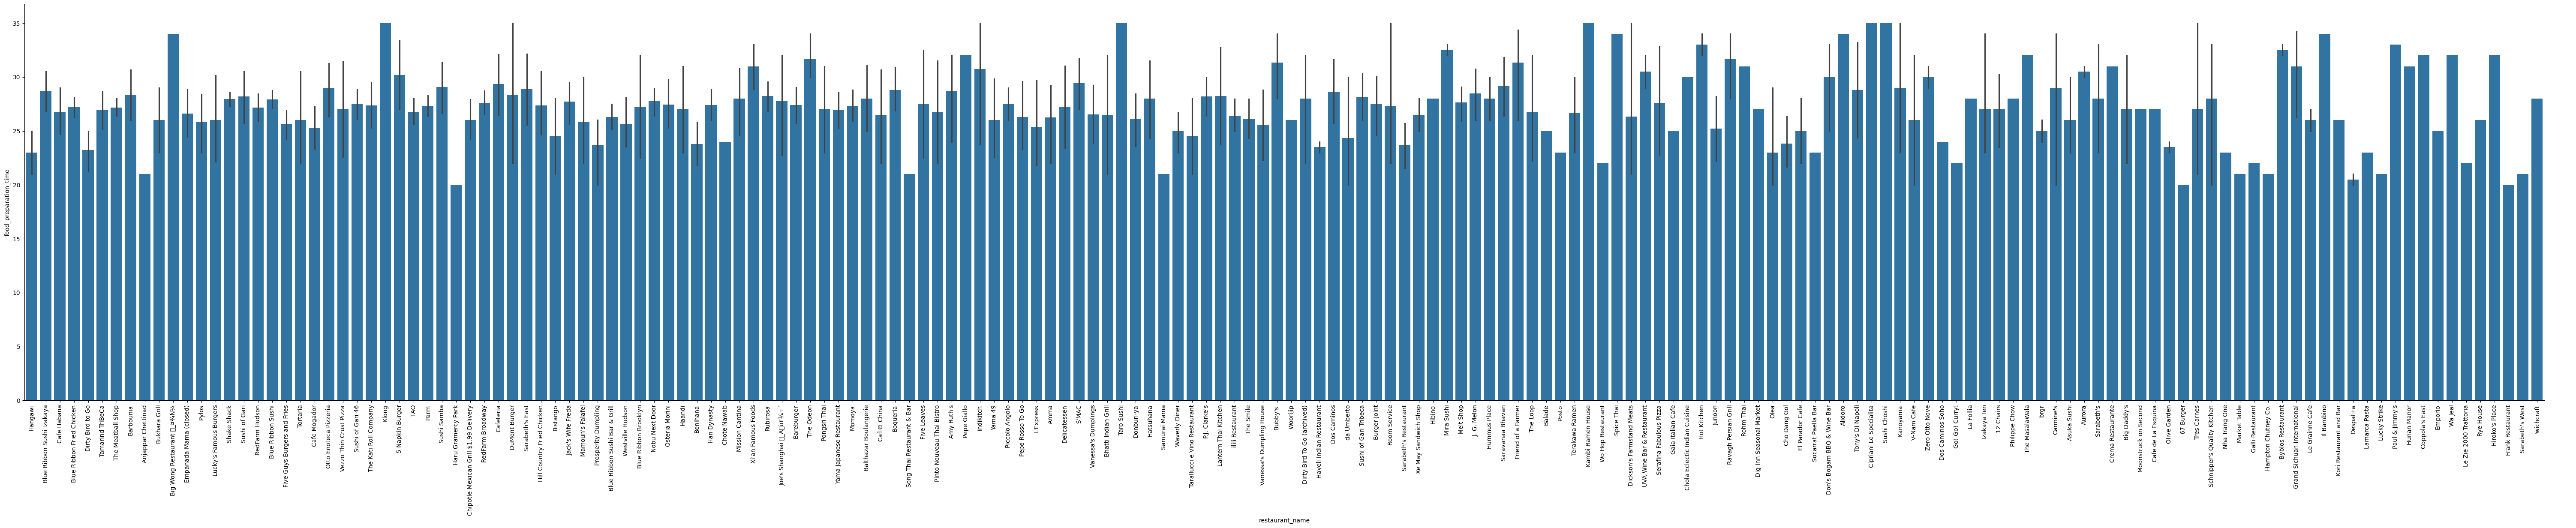

In [ ]:
sns.catplot(data = df, x = 'restaurant_name', y = 'food_preparation_time', kind = 'bar', height = 10, aspect = 6)
plt.xticks(rotation = 90)
%matplotlib inline

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 140 (\x8c) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 142 (\x8e) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 140 (\x8c) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 142 (\x8e) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 140 (\x8c) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 142 (\x8e) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core

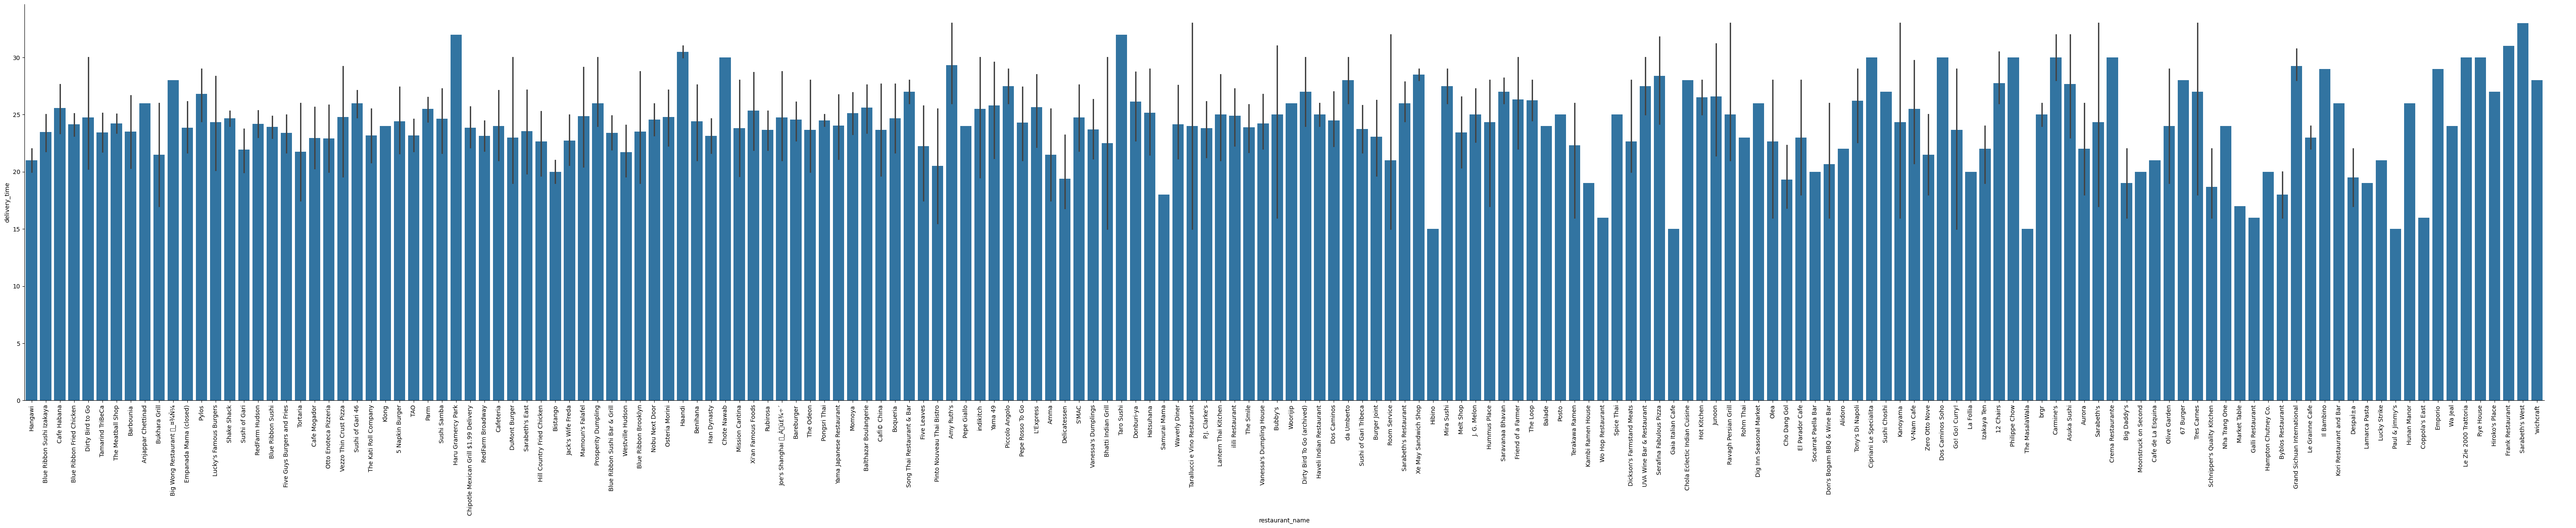

In [ ]:
sns.catplot(data = df, x = 'restaurant_name', y = 'delivery_time', kind = 'bar', height = 10, aspect = 6)
plt.xticks(rotation = 90)
%matplotlib inline

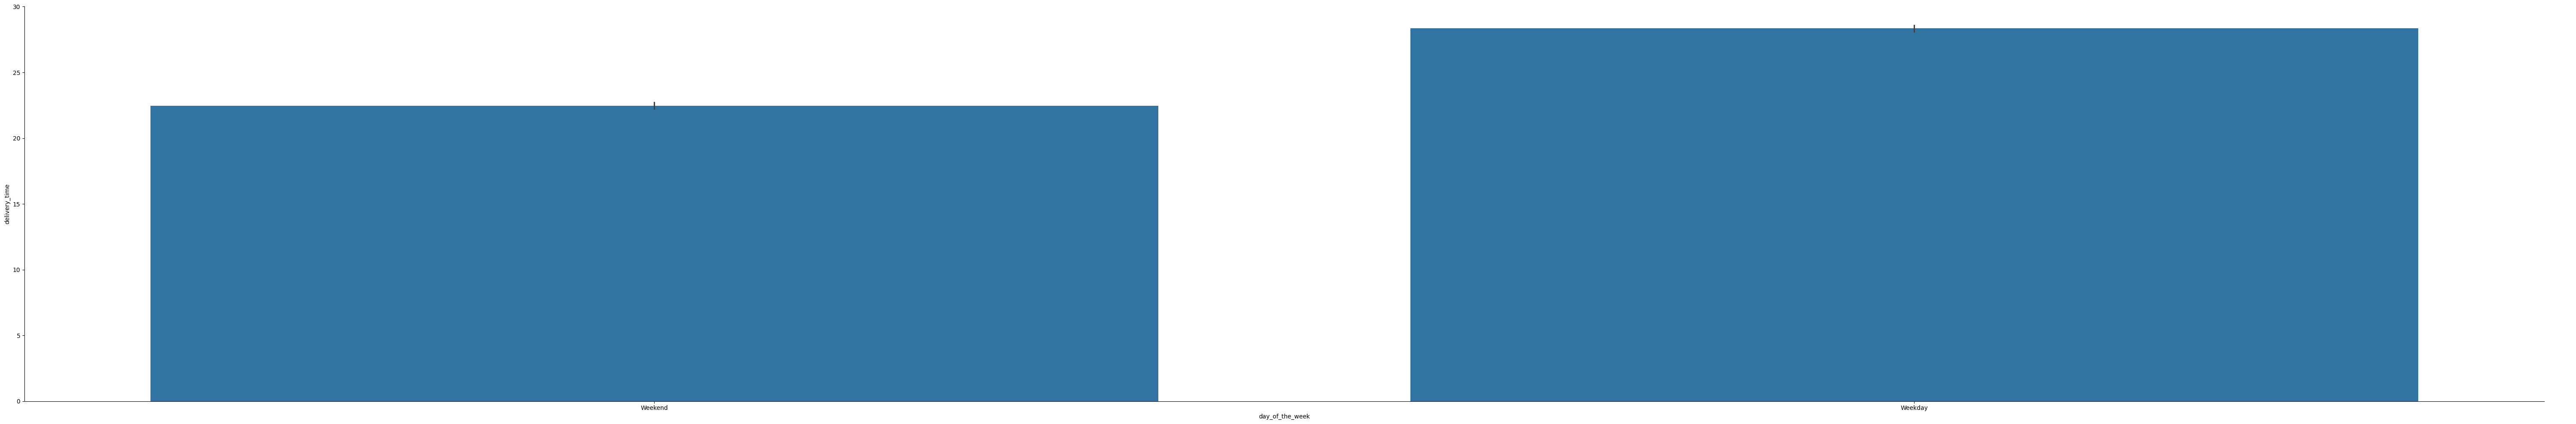

In [ ]:
sns.catplot(data = df, x = 'day_of_the_week', y = 'delivery_time', kind = 'bar', height = 10, aspect = 6)
%matplotlib inline

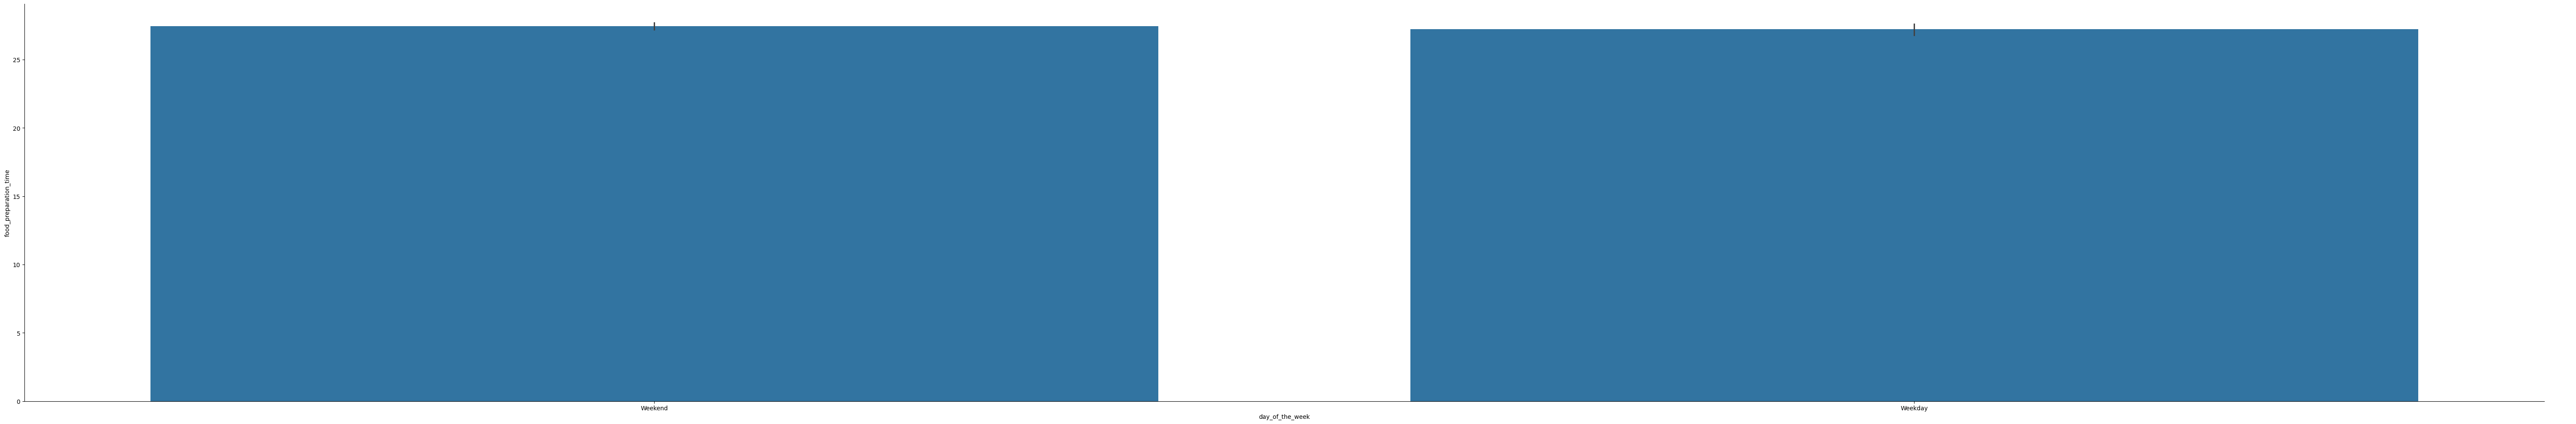

In [ ]:
sns.catplot(data = df, x = 'day_of_the_week', y = 'food_preparation_time', kind = 'bar', height = 10, aspect = 6)
%matplotlib inline

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
df['rating'].unique()
df_nan = df.replace(to_replace= 'Not given', value =np.nan)
df_nan['rating']= df_nan['rating'].astype(dtype = 'float')
df_nan['rating'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1898 entries, 0 to 1897
Series name: rating
Non-Null Count  Dtype  
--------------  -----  
1162 non-null   float64
dtypes: float64(1)
memory usage: 15.0 KB


In [ ]:
rest_rating = df_nan.groupby(['restaurant_name'])['rating'].mean().reset_index()
rest_count = df_nan.groupby(['restaurant_name'])['rating'].count().reset_index()
final_data = pd.merge(rest_rating, rest_count, on = 'restaurant_name', how = 'inner')
final_data.rename(columns = {'rating_x':'avg_rating', 'rating_y': 'rating_count'}, inplace = True)
final_data.head()

,restaurant_name,avg_rating,rating_count
0,'wichcraft,5.0,1
1,12 Chairs,4.5,2
2,5 Napkin Burger,4.0,2
3,67 Burger,5.0,1
4,Alidoro,NaN,0


In [ ]:
final_data[(final_data['avg_rating'] > 4) & (final_data['rating_count'] > 50)].sort_values(by = 'avg_rating', ascending = False)

,restaurant_name,avg_rating,rating_count
153,The Meatball Shop,4.511905,84
20,Blue Ribbon Fried Chicken,4.328125,64
136,Shake Shack,4.278195,133
21,Blue Ribbon Sushi,4.219178,73


#### Observations:
There are only 4 restaurants eligible for the promotional offer.

The meatball Shop comes in with the highest rating of approximately 4.51 and a rating count of 84, which is the second highest.

Blue Ribbon Fried Chicken with the second highest rating of approximately 4.33 and a rating count of 64, the lowest value.

Shake Shack with the third highest rating of approximately 4.28 and a rating count of 133, the highest value.

Blue Ribbon Sushi with the fifth highest rating of approximately 4.22 and a rating count of 73, the third highest value.


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
costs = df.cost_of_the_order

net_revenue = 0

for c in costs:
  if c > 20.0:
    net_revenue = net_revenue + (c * 0.25)

  elif 5.0 < c < 20:
    net_revenue = net_revenue + (c * 0.15)

  else:
    net_revenue = net_revenue + (c * 0)

print(f"Total Revenue is {round(net_revenue, 2)}")



Total Revenue is 6166.3


#### Observations:

Total Revenue is 6166.3 dollars.



### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
over_60_mins = df[df['delivery_time'] + df['food_preparation_time'] > 60]

over_60_mins_percent = round((100 * len(over_60_mins)/len(df)), 2)

print(over_60_mins_percent)


10.54


#### Observations:
Approximately, 10.54% of orders take more than 60 minutes to get delivered.

This could be due to the methods of preparation, traffic, the number of orders et cetera.

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [ ]:
week_delivery_time = df.groupby(['day_of_the_week'])['delivery_time'].mean().reset_index()
week_delivery_time.rename(columns={'delivery_time':'average delivery time'},inplace=True)
week_delivery_time.sort_values(ascending=False, by= 'average delivery time')

,day_of_the_week,average delivery time
0,Weekday,28.340037
1,Weekend,22.470022


#### Observations:

During weekdays, delivery time is approximately 28.34 minutes and on weekends 22.47 minutes.

This variance could be due to the amount of traffic on weekdays, the amount of orders to be delivered et cetera.



### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
* American cuisine has the most orders.
* Shake Shack has the most orders.
* Orders are more during the weekends.
* Orders are most when they cost around 10-15 dollars.
* Most orders were rated 5.
* It takes about 20-21 minutes to prepare most orders.
* It takes about 28.5 minutes to deliver most orders.
* The French cuisine has the highest cost of orders, with about 20 dollars. This may be due to quality, type of ingredients et cetera. However, the Vietnamese cuisine has the lowest cost of orders, with about 12 dollars.

* Kambi Ramen House has the highest cost of orders with about 32 dollars, while Big Wong Restaurant has the lowest cost of orders of about 6 dollars.
* Spanish cuisine has the highest rating of approximately 4.8, while
  Vietnamese has the lowest rating of approximately 4.1.

  Southern and French cuisines have the same rating of approximately 4.3.

  This could be due to food preparation and delivery time, quality of food et cetera.
* The weekend has a rating of 4.5, while the weekday has a rating of about 4.3.

  This is only a slight difference.


* The Southern cuisine has the highest food preparation time of about 27 minutes, while the Korean cuisine has the lowest food preparation time of about 25.5 minutes.

* Approximately, the weekend has 16.3 dollars as its cost of orders, while the weekday has 16.1 dollrs as its cost of orders.

This could be due to more customers during the weekends so as to maximise profit.



### Recommendations:

*  Restaurants should ensure to reduce their food preparation time. This could be by employing more labour, investing in machines, et cetera, to prioritise efficiency and increase customer satisfaction, therefore increasing ratings.

* Customers should be pushed to give their rating to allow restaurants gauge their satisfaction and work on their services.
* Restaurants should diversify into more demanded cuisines, for example the American cuisine, which is the most ordered.
* Restaurants which do not have much orders should offer incentives, for example discounts and aggressive advertisement.
* Restaurants with already high ratings should strive to maintain their quality and efficiency with for example, broaden their menu and offer discounts and loyalty programs.
* Restaurants should increase their efficiency during weekdays. They should offer weekday only discounts and specials and advertise aggressively during weekdays, especially lunch hours.
* Delivery should be quick. Customers should be notified of the exact and realistic time delivery should take. The fastest routes should be taken and when delays occur, discounts or free items should be provided.
* Restaurants with low orders should increase their availability in multiple locations so as to access more customers.

---